<div style="border-radius:10px;overflow:hidden;font-family:Aptos,Calibri,Segoe UI,sans-serif;border:1px solid #e6e9ee">
  <div style="background:#0A2540;padding:18px 22px;color:#fff">
    <div style="font-size:12px;letter-spacing:2px;color:#F4B942;font-weight:700">CARISURG · MEDTECH PATHWAYS · WEEK 5 · TUTORIAL 2</div>
    <div style="font-size:24px;font-weight:700;margin-top:4px">Data Profiling</div>
    <div style="font-size:14px;color:#cdd6df;margin-top:6px">Measuring missingness, types, distributions and outliers across 225 features.</div></div>
  <div style="background:#F4B942;color:#0A2540;padding:6px 22px;font-size:12px;font-weight:700;letter-spacing:1px">STUDENT NOTEBOOK</div></div>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Goal
Turn eyeballing into measurement. With 225 columns we profile the **structured** features in detail and the **chief-complaint** family in aggregate. Output: a data-quality issues table for the Tutorial 5 memo.

## 1 · Setup

In [ ]:
# Run this cell first. These are the three libraries we use all week.
import numpy as np                 # numerical helpers (NaN, medians, etc.)
import pandas as pd                # tables / DataFrames — our main tool
import matplotlib.pyplot as plt    # plotting

# Let pandas show more of a wide table when we print it:
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Environment ready · pandas", pd.__version__)

Environment ready · pandas 2.2.2


In [ ]:
# ── Schema map ────────────────────────────────────────────────────────────────
# This dataset has ~225 columns, so we never list them by hand. We sort them into
# "families" once, then refer to the families by name for the rest of the week.

TARGET = "esi"   # Emergency Severity Index: 1 (most urgent) .. 5 (least). Our triage label.

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

def classify_columns(df):
    """Sort the DataFrame's columns into families and return them in a dictionary."""

    # Helper: from a wish-list of names, keep only the ones that really exist in df.
    # (A plain function instead of a lambda, so it is easy to read.)
    def keep_present(wanted):
        present = []
        for col in wanted:
            if col in df.columns:
                present.append(col)
        return present

    # The ~200 chief-complaint columns all start with "cc_", so we find them by prefix:
    chief_complaints = []
    for col in df.columns:
        if col.startswith("cc_"):
            chief_complaints.append(col)

    families = {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }
    return families

In [ ]:
# Reference ranges for general adult triage. Each entry is (low, high, unit).
# NOTE: temperature is in FAHRENHEIT in this dataset (≈98.6 normal), not Celsius!
NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), "triage_glucose": (70,140,"mg/dL")}

# "Plausible" bounds are much wider than normal — anything OUTSIDE these is treated as a
# data error (e.g. a heart rate of 5). Each entry is (low, high).
PLAUSIBLE = {"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_glucose": (20,800)}

In [13]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("/content/yaleemmlc_admissionprediction_triage.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find {DATA_PATH}. Set DATA_PATH (Colab) or place the CSV beside this notebook.")

# First, peek at the raw file to sanity check it's really a CSV and see its size
print("File size (MB):", DATA_PATH.stat().st_size / 1_000_000)
with open(DATA_PATH, encoding="utf-8", errors="replace") as f:
    for i in range(3):
        print(f.readline())

# Now try reading it, skipping any malformed rows instead of crashing
df = pd.read_csv(DATA_PATH, index_col=0, on_bad_lines="warn", engine="python")
print(f"Loaded {df.shape[0]:,} encounters x {df.shape[1]} columns")

File size (MB): 46.121002
,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,cc_abscess,cc_addictionproblem,cc_agitation,cc_alcoholintoxication,cc_alcoholproblem,cc_allergicreaction,cc_alteredmentalstatus,cc_animalbite,cc_ankleinjury,cc_anklepain,cc_anxiety,cc_arminjury,cc_armpain,cc_armswelling,cc_assaultvictim,cc_asthma,cc_backpain,cc_bleeding/bruising,cc_blurredvision,cc_bodyfluidexposure,cc_breastpain,cc_breathingdifficulty,cc_breathingproblem,cc_burn,cc_cardiacarrest,cc_cellulitis,cc_chestpain,cc_chesttightness,cc_chills,cc_coldlikesymptoms,cc_confusion,cc_conjunctivitis,cc_constipation,cc_cough,cc_cyst,cc_decreasedbloodsug

/tmp/ipykernel_7681/2433718250.py:16: ParserWarning: Skipping line 2121: Expected 226 fields in line 2121, saw 339

  df = pd.read_csv(DATA_PATH, index_col=0, on_bad_lines="warn", engine="python")


Loaded 46,636 encounters x 225 columns


In [14]:
fam = classify_columns(df)
# "structured" = the non-chief-complaint columns (everything not starting with "cc_").
structured = [col for col in df.columns if not col.startswith("cc_")]

## 2 · Missingness (structured columns)

Chief-complaint flags are 0/1, not missing — so we profile missingness on the structured columns.

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Measure the <b>fraction missing</b> in each structured column, turn it into a percentage, and show only the columns that actually have gaps (worst first). The cell gives you the steps and the function names — you write the code.</div>

In [15]:
# .isna() marks every cell True/False for "is this missing?".
# GOAL: a percentage-missing per structured column, worst first, gaps only.

# TODO 1 — FRACTION MISSING PER COLUMN
# HINT: df[structured].isna() gives True/False; taking .mean() of True/False = the fraction missing.
missing_fraction = df[structured].isna().mean()      # <- replace: add .mean() to get one fraction per column

# TODO 2 — TURN INTO A PERCENTAGE, worst first
# HINT: multiply by 100 and .round(1), then .sort_values(ascending=False).
missing_percent = (missing_fraction * 100).round(1)
missing_percent = missing_percent.sort_values(ascending=False)

# TODO 3 — SHOW ONLY COLUMNS WITH GAPS
# HINT: filter a Series with a mask -> missing_percent[missing_percent > 0]
missing_percent[missing_percent > 0]

,0


<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>.isna()</code> turns the table into True/False — True wherever a cell is empty. Taking <code>.mean()</code> of True/False gives the <b>fraction</b> that are True, i.e. the share missing (True = 1, False = 0). And <code>missing_percent[missing_percent &gt; 0]</code> filters a Series with a True/False mask: it keeps only the rows where the condition holds.</div>

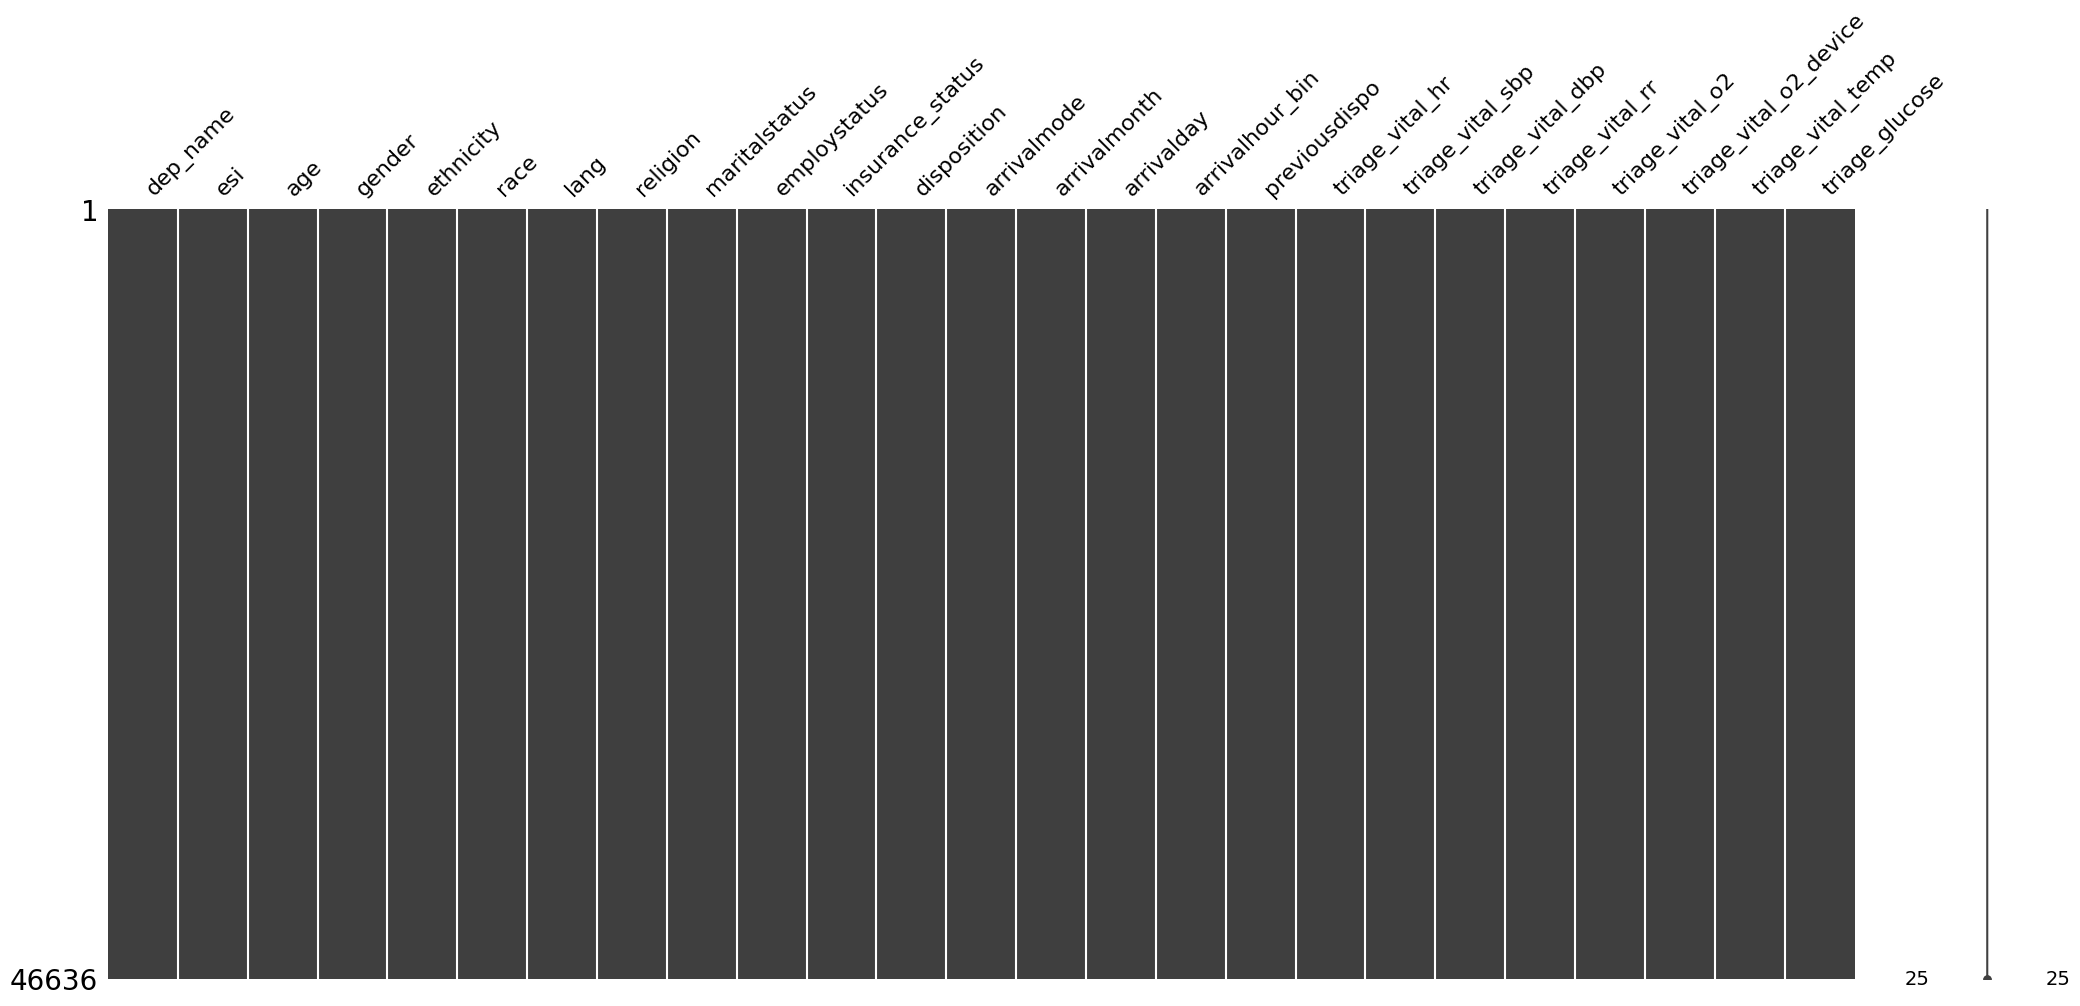

In [16]:
# Missingness map of the structured block (a 226-col map is unreadable)
try:
    import missingno as msno              # Colab: !pip install missingno -q
    msno.matrix(df[structured]); plt.show()
except Exception:
    fig, ax = plt.subplots(figsize=(11,4))
    ax.imshow(df[structured].isna().values, aspect="auto", cmap="gray_r")
    ax.set_xticks(range(len(structured))); ax.set_xticklabels(structured, rotation=90, fontsize=7)
    ax.set_title("Missing cells — structured columns (dark = missing)"); plt.tight_layout(); plt.show()

<div style="border-left:4px solid #1B9AAA;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#1B9AAA">🩺 CLINICAL CONTEXT</b><br>Watch <code>esi</code> missingness especially: a row with no triage label cannot teach a triage model, so those rows are candidates for removal (Tutorial 3) — not imputation. You never invent a triage decision.</div>

## 3 · Dtype audit + target sanity

In [17]:
print(df[structured].dtypes)
print("\nESI value counts (raw):"); print(df[TARGET].value_counts(dropna=False).sort_index())

dep_name                   object
esi                       float64
age                       float64
gender                     object
ethnicity                  object
race                       object
lang                       object
religion                   object
maritalstatus              object
employstatus               object
insurance_status           object
disposition                object
arrivalmode                object
arrivalmonth               object
arrivalday                 object
arrivalhour_bin            object
previousdispo              object
triage_vital_hr           float64
triage_vital_sbp          float64
triage_vital_dbp          float64
triage_vital_rr           float64
triage_vital_o2           float64
triage_vital_o2_device    float64
triage_vital_temp         float64
triage_glucose            float64
dtype: object

ESI value counts (raw):
esi
1.0       70
2.0    15203
3.0    22816
4.0     7519
5.0     1028
Name: count, dtype: int64


<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>.dtypes</code> reports what <i>kind</i> of value each column holds — <code>float64</code> for numbers, <code>object</code> (or <code>str</code>) when text has sneaked into a numeric column. <code>.value_counts()</code> tallies how often each distinct value appears; <code>dropna=False</code> adds a row for the NaNs so missing labels can’t hide; <code>.sort_index()</code> orders the tally by ESI level (1→5).</div>

## 4 · Distributions

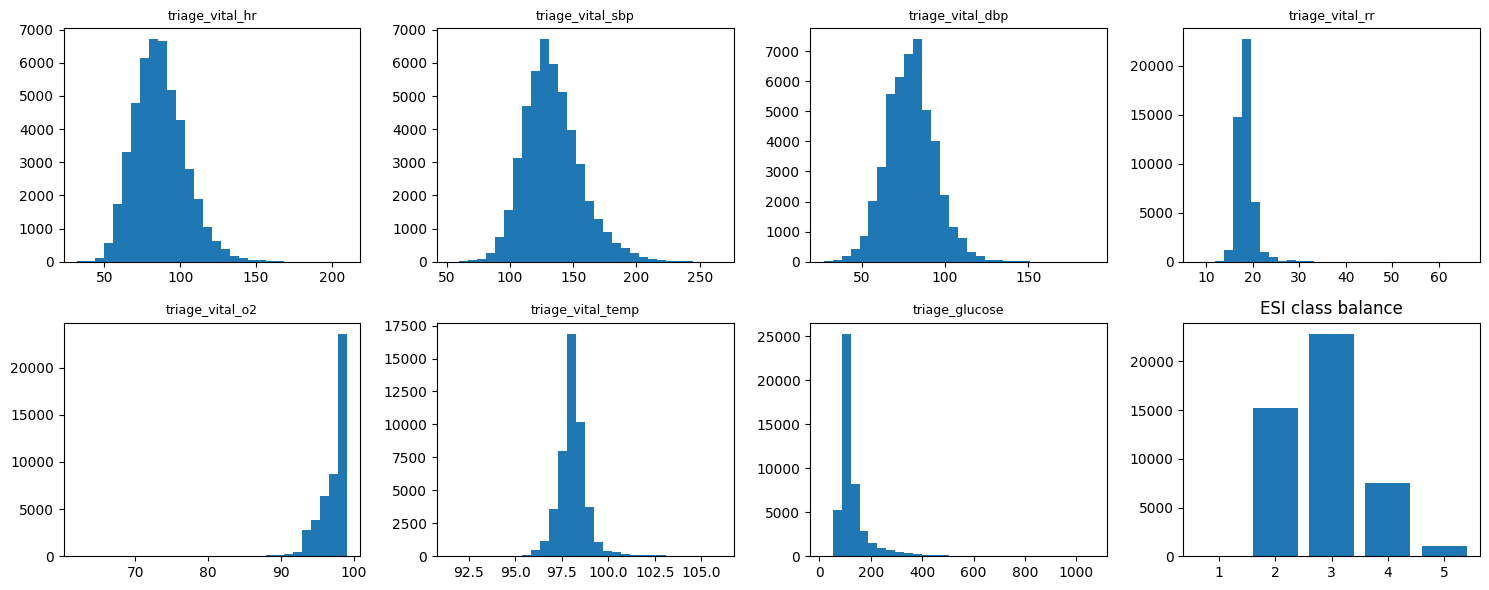

In [18]:
# Draw a histogram for each vital. (The instructor version also adds an ESI bar.)
vitals = fam["vitals"]
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
panels = axes.ravel()           # flatten the 2x4 grid into a list of 8 panels

for panel, col in zip(panels, vitals):
    # TODO: turn df[col] into numbers with pd.to_numeric(..., errors="coerce"), drop NaNs,
    #       then call panel.hist(values, bins=30) and panel.set_title(col).
    values = pd.to_numeric(df[col], errors="coerce").dropna()
    panel.hist(values, bins=30)
    panel.set_title(col, fontsize=9)
    pass

esi_counts = df[TARGET].value_counts().sort_index()
panels[-1].bar(esi_counts.index, esi_counts.values)
panels[-1].set_title("ESI class balance")

plt.tight_layout(); plt.show()

<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>pd.to_numeric(df[col], errors='coerce')</code> forces a column to numbers and quietly turns anything it can’t parse (like <code>'120bpm'</code>) into NaN instead of crashing — <code>coerce</code> = ‘don’t raise an error, just mark it missing’. <code>.dropna()</code> then drops those gaps so the histogram only plots real numbers. <code>zip(panels, vitals)</code> pairs panel 1 with vital 1, panel 2 with vital 2, and so on, so one loop fills the whole grid.</div>

In [19]:
# Demographics — the fairness-sensitive view (raw categories)
for c in ["race","ethnicity","insurance_status"]:
    print(c, "->", df[c].value_counts(dropna=False).to_dict())

race -> {'White or Caucasian': 25063, 'Black or African American': 12975, 'Other': 7972, 'Patient Refused': 319, 'Asian': 168, 'Unknown': 71, 'American Indian or Alaska Native': 49, 'Native Hawaiian or Other Pacific Islander': 19}
ethnicity -> {'Non-Hispanic': 37859, 'Hispanic or Latino': 8705, 'Patient Refused': 45, 'Unknown': 27}
insurance_status -> {'Medicaid': 18247, 'Medicare': 14744, 'Commercial': 11864, 'Other': 1629, 'Self pay': 152}


## 5 · Outliers — statistical vs clinically impossible

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Finish <code>outlier_report</code> so it returns two counts per vital: <b>statistical</b> outliers (the 1.5×IQR fence) and <b>clinically impossible</b> values (outside plausible bounds). The function names you need are in the hints.</div>

In [20]:
def outlier_report(df, col):
    """Count two kinds of outlier in one numeric column."""
    x = pd.to_numeric(df[col], errors="coerce").dropna()   # numbers only

    # TODO 1 — STATISTICAL OUTLIERS (the 1.5 x IQR "fence")
    # HINT: q1 = x.quantile(0.25); q3 = x.quantile(0.75); iqr = q3 - q1
    # HINT: count them with ((x < q1 - 1.5*iqr) | (x > q3 + 1.5*iqr)).sum()  -- keep the parentheses
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    low_fence = q1 - 1.5*iqr
    high_fence = q3 + 1.5*iqr
    iqr_outliers = ((x < low_fence) | (x > high_fence)).sum()

    # TODO 2 — CLINICALLY IMPOSSIBLE (outside the wide plausible bounds)
    # HINT: hard_low, hard_high = PLAUSIBLE.get(col, (-np.inf, np.inf))
    # HINT: count them with ((x < hard_low) | (x > hard_high)).sum()
    hard_low, hard_high = PLAUSIBLE.get(col, (-np.inf, np.inf))
    impossible = ((x < hard_low) | (x > hard_high)).sum()

    return {"iqr_outliers": iqr_outliers, "impossible": impossible}

report_rows = {}
for col in fam["vitals"]:
    report_rows[col] = outlier_report(df, col)
pd.DataFrame(report_rows).T

,iqr_outliers,impossible
triage_vital_hr,554,0
triage_vital_sbp,876,0
triage_vital_dbp,627,0
triage_vital_rr,1998,4
triage_vital_o2,1255,0
triage_vital_temp,3050,0
triage_glucose,4754,23


<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br>Two ideas here. <code>x.quantile(0.25)</code>/<code>0.75</code> are the 25th/75th percentiles; the IQR ‘fence’ flags statistically unusual values. Combining masks needs <b>parentheses</b> and <code>|</code> (‘or’): <code>(x &lt; low) | (x &gt; high)</code> is True wherever either holds. Finally <code>pd.DataFrame(report_rows).T</code> builds a table, and <code>.T</code> flips rows and columns so each vital becomes a row.</div>

## 6 · Relationship with the real target

No provisional label this time — `esi` is real. Which vitals and complaints move with acuity?

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Measure how each vital and each chief complaint <b>correlates with <code>esi</code></b>, and print the strongest. Remember the sign: a <b>negative</b> correlation means the value rises as <code>esi</code> falls — i.e. it tracks <i>higher</i> acuity.</div>

In [25]:
# Make a numeric copy of the vitals so we can correlate them with ESI.
vitals_numeric = df[fam["vitals"]].copy()
for col in fam["vitals"]:
    vitals_numeric[col] = pd.to_numeric(vitals_numeric[col], errors="coerce")

# TODO 1 — VITALS vs ESI
vital_corr = vitals_numeric.corrwith(df[TARGET]).sort_values()
print("Vital vs ESI:")
print(vital_corr.round(3))

# TODO 2 — CHIEF COMPLAINTS vs ESI
# Coerce to numeric first — some cc_ columns contain stray string values (e.g. '0.00.0')
cc_numeric = df[fam["chief_complaints"]].copy()
for col in fam["chief_complaints"]:
    cc_numeric[col] = pd.to_numeric(cc_numeric[col], errors="coerce")

cc_corr = cc_numeric.corrwith(df[TARGET]).dropna().sort_values()
print("\nChief Complaints vs ESI:")
print(cc_corr.head(8).round(3))

Vital vs ESI:
triage_vital_rr     -0.095
triage_vital_hr     -0.094
triage_glucose      -0.079
triage_vital_temp   -0.022
triage_vital_sbp     0.002
triage_vital_dbp     0.049
triage_vital_o2      0.177
dtype: float64

Chief Complaints vs ESI:
cc_chestpain               -0.162
cc_shortnessofbreath       -0.149
cc_suicidal                -0.144
cc_alcoholintoxication     -0.140
cc_alteredmentalstatus     -0.132
cc_psychiatricevaluation   -0.103
cc_weakness                -0.079
cc_syncope                 -0.076
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>.copy()</code> makes a separate copy so editing it never touches the original <code>df</code>. <code>.corrwith(df[TARGET])</code> correlates <i>every</i> column against one target Series in a single step, returning one number per column between −1 and +1. A <b>negative</b> value means ‘as this vital goes up, <code>esi</code> goes down’ — and lower <code>esi</code> means more urgent.</div>

<div style="border-left:4px solid #C0392B;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#C0392B">⚠️ DATA / SAFETY NOTE</b><br>Correlations here are <b>directional sanity checks</b> on a real but US-sourced label, not model performance and not causal. Many <code>cc_</code> flags are near-zero-variance, so their correlations are unstable — note that, do not over-read them.</div>

## 7 · Data-quality issues table

In [26]:
issues = [
    {"issue": "Missing ESI label",
     "columns": "esi",
     "action": "drop rows without a target label (verify count is 0 first)"},

    {"issue": "Missing vitals",
     "columns": "triage_vital_hr, _sbp, _dbp, _rr, _o2, _temp, triage_glucose",
     "action": "check missingness rate per vital; investigate if missing is random or acuity-related"},

    {"issue": "Impossible / extreme vital values",
     "columns": "triage_vital_hr, _sbp, _dbp, _rr, _o2, _temp, triage_glucose",
     "action": "flag or cap physiologically implausible readings (e.g. HR > 250, SBP < 30)"},

    {"issue": "Temperature recorded in Fahrenheit",
     "columns": "triage_vital_temp",
     "action": "document units clearly; never assume/convert to Celsius without checking"},

    {"issue": "Sparse / near-constant cc_ flags",
     "columns": "cc_* (200 flags)",
     "action": "drop or group flags below a chosen prevalence threshold (e.g. <0.5%)"},

    {"issue": "Leakage risk",
     "columns": "disposition",
     "action": "exclude entirely from any triage-time model — only known after triage"},

    {"issue": "Representativeness / transfer risk",
     "columns": "race, ethnicity, insurance_status, arrivalmode",
     "action": "flag as US-specific; re-validate before any Caribbean ED deployment"},
]
pd.DataFrame(issues)

,issue,columns,action
0,Missing ESI label,esi,drop rows without a target label (verify count...
1,Missing vitals,"triage_vital_hr, _sbp, _dbp, _rr, _o2, _temp, ...",check missingness rate per vital; investigate ...
2,Impossible / extreme vital values,"triage_vital_hr, _sbp, _dbp, _rr, _o2, _temp, ...",flag or cap physiologically implausible readin...
3,Temperature recorded in Fahrenheit,triage_vital_temp,document units clearly; never assume/convert t...
4,Sparse / near-constant cc_ flags,cc_* (200 flags),drop or group flags below a chosen prevalence ...
5,Leakage risk,disposition,exclude entirely from any triage-time model — ...
6,Representativeness / transfer risk,"race, ethnicity, insurance_status, arrivalmode",flag as US-specific; re-validate before any Ca...


## 8 · Exercises
1. Complete `outlier_report` and the target-correlation cell.
2. Is vitals missingness related to acuity? Compare ESI for rows missing `triage_vital_o2` vs not.
3. How many `cc_` columns are effectively constant (<0.5% prevalence)? What does that imply for modelling?
4. Finish the issues table — every problem gets a row and a planned action.

In [27]:
def outlier_report(df, plausible_ranges):
    """For each column with a plausible range, count values falling outside it."""
    rows = []
    for col, (lo, hi) in plausible_ranges.items():
        if col not in df.columns:
            continue
        vals = pd.to_numeric(df[col], errors="coerce")
        n_below = (vals < lo).sum()
        n_above = (vals > hi).sum()
        rows.append({
            "column": col,
            "plausible_range": f"{lo}–{hi}",
            "below_range": int(n_below),
            "above_range": int(n_above),
            "total_outliers": int(n_below + n_above),
            "pct_outliers": round((n_below + n_above) / len(df) * 100, 2)
        })
    return pd.DataFrame(rows).sort_values("total_outliers", ascending=False)

outlier_report(df, PLAUSIBLE)

,column,plausible_range,below_range,above_range,total_outliers,pct_outliers
8,triage_glucose,20–800,3,20,23,0.05
5,triage_vital_rr,4–60,0,4,4,0.01
0,age,0–120,0,0,0,0.00
1,esi,1–5,0,0,0,0.00
2,triage_vital_hr,20–250,0,0,0,0.00
4,triage_vital_dbp,20–200,0,0,0,0.00
3,triage_vital_sbp,50–300,0,0,0,0.00
6,triage_vital_o2,50–100,0,0,0,0.00
7,triage_vital_temp,86–110,0,0,0,0.00


In [28]:
missing_o2 = df["triage_vital_o2"].isna()

print("ESI when triage_vital_o2 is MISSING:")
print(df.loc[missing_o2, "esi"].describe())

print("\nESI when triage_vital_o2 is PRESENT:")
print(df.loc[~missing_o2, "esi"].describe())

ESI when triage_vital_o2 is MISSING:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: esi, dtype: float64

ESI when triage_vital_o2 is PRESENT:
count    46636.000000
mean         2.876319
std          0.752404
min          1.000000
25%          2.000000
50%          3.000000
75%          3.000000
max          5.000000
Name: esi, dtype: float64


In [29]:
cc_numeric = df[fam["chief_complaints"]].apply(pd.to_numeric, errors="coerce")
cc_prevalence = cc_numeric.mean()  # proportion of 1s per flag
rare_flags = cc_prevalence[cc_prevalence < 0.005]

print(f"Number of cc_ flags below 0.5% prevalence: {len(rare_flags)} out of {len(cc_prevalence)}")
print(rare_flags.sort_values())

Number of cc_ flags below 0.5% prevalence: 149 out of 200
cc_cardiacarrest                     0.000000
cc_fulltrauma                        0.000086
cc_hyperglycemia                     0.000193
cc_ingestion                         0.000193
cc_trauma                            0.000193
                                       ...   
cc_constipation                      0.004503
cc_elevatedbloodsugar-symptomatic    0.004524
cc_generalizedbodyaches              0.004675
cc_dentalpain                        0.004825
cc_sicklecellpain                    0.004975
Length: 149, dtype: float64


## 9 · Wrap-up
You have measured the quality. **Next — Tutorial 3: Cleaning**, where each issue gets a documented fix.